# Experiment 03 - 48h run detail (8 probes x 10 sites)

`run_20260612_48h` (2026-06-14 19:25 -> 2026-06-16 19:16 PKT). Built to catch CDN
serving-location flips and probe outages over two diurnal cycles. All times PKT.
Sections: reachability, **outages (who goes dark and when)**, per-ISP RTT, CDN PoP
flips, diurnal, path changes, dynamic ASN. Companion to
`findings/03_longitudinal_routing_48h.md`.

In [1]:
import glob, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates

RESULTS = '../experiments/03_longitudinal_routing/results/run_20260612_48h'
ts_file = sorted(glob.glob(os.path.join(RESULTS, 'trace_summary_2026*.csv')))[-1]
pg_file = sorted(glob.glob(os.path.join(RESULTS, 'ping_series_2026*.csv')))[-1]

def to_pkt(col):  # UTC string -> naive PKT (UTC+5) so axes label in local time
    return pd.to_datetime(col).dt.tz_convert('Asia/Karachi').dt.tz_localize(None)

df = pd.read_csv(ts_file)
df['t'] = to_pkt(df['trace_time']); df['hr'] = df['t'].dt.floor('h'); df['hour'] = df['t'].dt.hour
ok = df[df['destination_responded']]
pg = pd.read_csv(pg_file); pg['t'] = to_pkt(pg['ping_time'])
PROBES = sorted(df['probe_city'].unique())

def fmt_time(ax, every=12):
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, every)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d %H:%M'))
    ax.tick_params(axis='x', labelsize=8)

print('trace rounds:', len(df), '| probes:', len(PROBES), '| sites:', df['target_label'].nunique())
print('span PKT:', df['t'].min(), '->', df['t'].max())

trace rounds: 14319 | probes: 8 | sites: 10
span PKT: 2026-06-14 19:25:33 -> 2026-06-16 19:16:46


## 1. Reachability

Which sites reply to ICMP at all. Dunya News and FBR reply 0% but the traceroutes
still reach their networks, so they are firewalling ICMP, not down.

In [2]:
reach = (df.groupby('target_label')['destination_responded'].mean() * 100).round(1).sort_values()
display(reach.rename('reachable_%').to_frame())
print('ICMP-blocked (0% reply, path still reaches network):',
      sorted(reach[reach == 0].index))

,reachable_%
target_label,
Dunya News,0.0
FBR,0.0
Telemart,88.5
MCB Bank,93.6
Geo TV,93.8
Dawn,93.9
Express,93.9
NADRA,94.1
HBL Bank,94.5


ICMP-blocked (0% reply, path still reaches network): ['Dunya News', 'FBR']


## 2. Outages - who goes dark, and when

A **probe** outage shows as no results to any site (its rounds/hour drop to 0). A
**site** outage shows as a row going red across all probes. The first chart is probe
liveness over time; the gap scan prints exact windows; the heatmap shows site
reachability per hour (Dunya/FBR are red throughout = ICMP-blocked, not an outage).

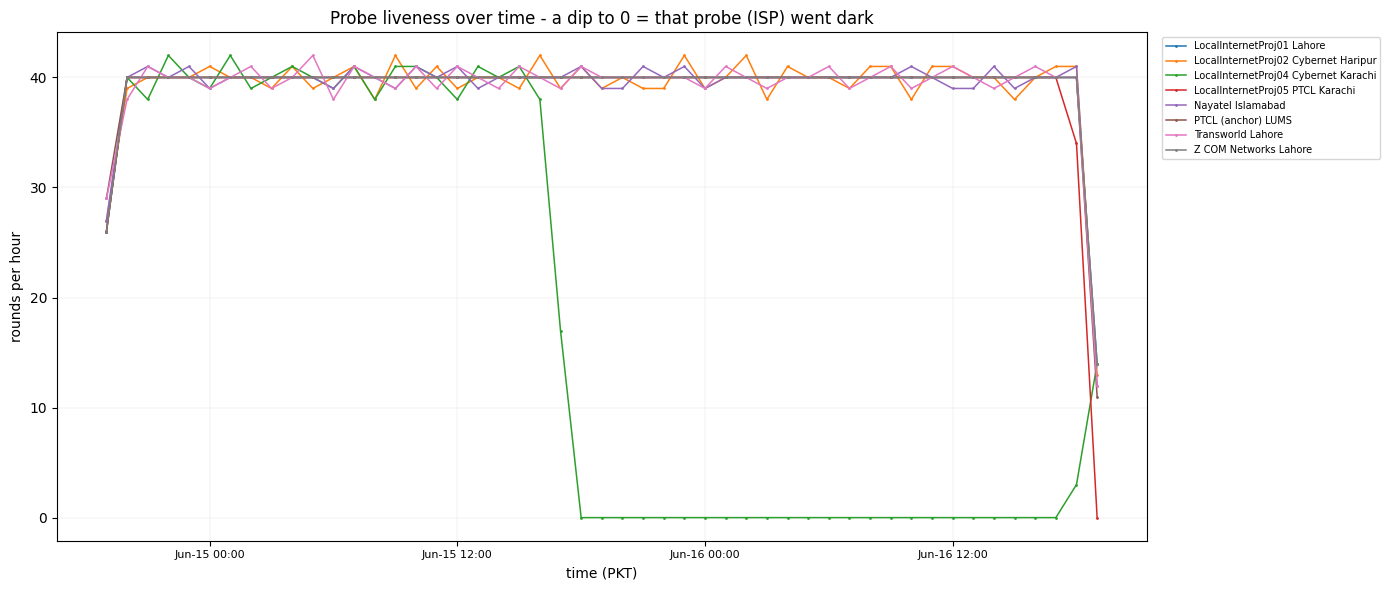

Probe outage windows (gap > 25 min between consecutive rounds):
  LocalInternetProj04 Cybernet Karachi DOWN Jun-15 17:26 -> UP Jun-16 18:58 PKT  (25.5 h)


In [3]:
# --- probe liveness: rounds per hour (≈ sites x 4 = ~40 when up; 0 = outage) ---
ct = df.groupby(['hr', 'probe_city']).size().unstack('probe_city').reindex(columns=PROBES).fillna(0)
fig, ax = plt.subplots(figsize=(14, 6))
for p in PROBES:
    ax.plot(ct.index, ct[p], lw=1.1, marker='.', ms=2, label=p)
ax.set_ylabel('rounds per hour'); ax.set_xlabel('time (PKT)')
ax.set_title('Probe liveness over time - a dip to 0 = that probe (ISP) went dark')
fmt_time(ax); ax.grid(True, lw=0.3, alpha=0.4)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()

# --- exact outage windows ---
print('Probe outage windows (gap > 25 min between consecutive rounds):')
any_out = False
for probe, g in df.groupby('probe_city'):
    tps = g['t'].sort_values().drop_duplicates().reset_index(drop=True)
    for i in range(1, len(tps)):
        d = (tps[i] - tps[i-1]).total_seconds() / 60
        if d > 25:
            any_out = True
            print(f'  {probe:<34} DOWN {tps[i-1]:%b-%d %H:%M} -> UP {tps[i]:%b-%d %H:%M} PKT  ({d/60:.1f} h)')
if not any_out:
    print('  none')

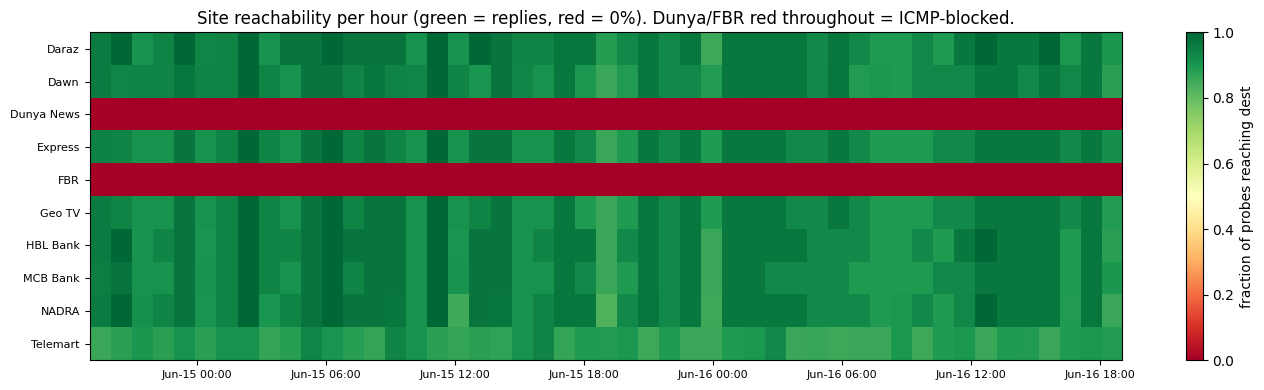

In [4]:
# --- site reachability heatmap (site x hour): green = replying, red = 0% ---
rr = df.groupby(['hr', 'target_label'])['destination_responded'].mean().unstack('target_label')
x0, x1 = mdates.date2num(rr.index[0]), mdates.date2num(rr.index[-1])
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(rr.T.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1,
               extent=[x0, x1, len(rr.columns), 0], interpolation='nearest')
ax.set_yticks([i + 0.5 for i in range(len(rr.columns))]); ax.set_yticklabels(rr.columns, fontsize=8)
ax.xaxis_date(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d %H:%M')); ax.tick_params(axis='x', labelsize=8)
ax.set_title('Site reachability per hour (green = replies, red = 0%). Dunya/FBR red throughout = ICMP-blocked.')
plt.colorbar(im, ax=ax, label='fraction of probes reaching dest'); plt.tight_layout(); plt.show()

## 3. Per-ISP RTT (responding sites)

Median RTT for each site by probe. Note the Cloudflare rows (Dawn, Express, Geo,
Telemart): Nayatel and Cybernet reach a local edge (a few ms) while the PTCL probes
are 100-280 ms for the same content.

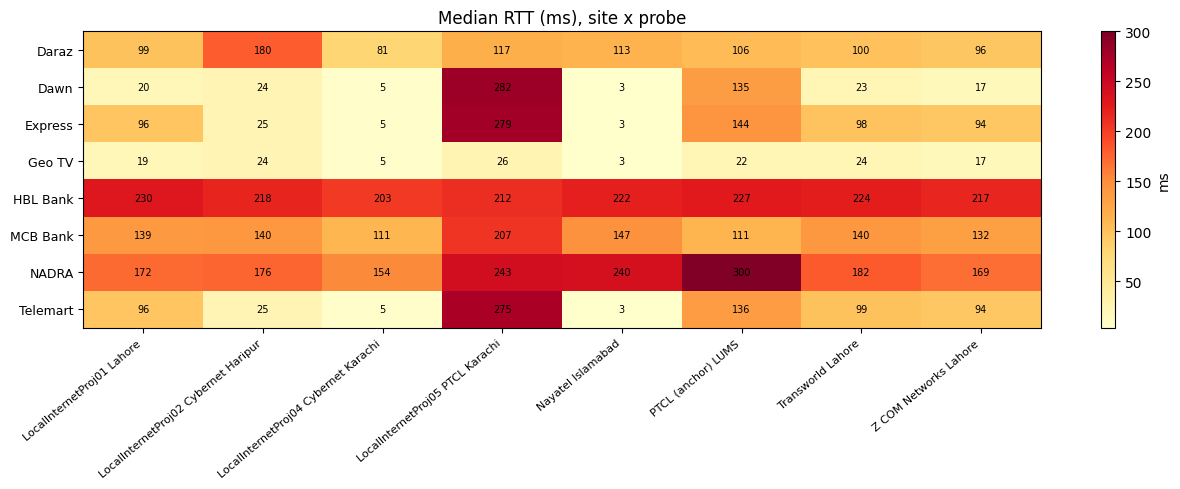

In [5]:
piv = ok.pivot_table(index='target_label', columns='probe_city', values='dest_rtt_ms', aggfunc='median')
piv = piv.reindex(columns=PROBES)
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(piv.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index, fontsize=9)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if pd.notna(v): ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7)
ax.set_title('Median RTT (ms), site x probe'); plt.colorbar(im, ax=ax, label='ms')
plt.tight_layout(); plt.show()

## 4. CDN serving-location flips (PoP)

For an anycast / GeoDNS site, each round is coloured by the metro the CDN served it
from. When the colour (and the RTT level) jumps, the serving edge moved. NADRA
(Akamai) and MCB (Sucuri) are the big movers.

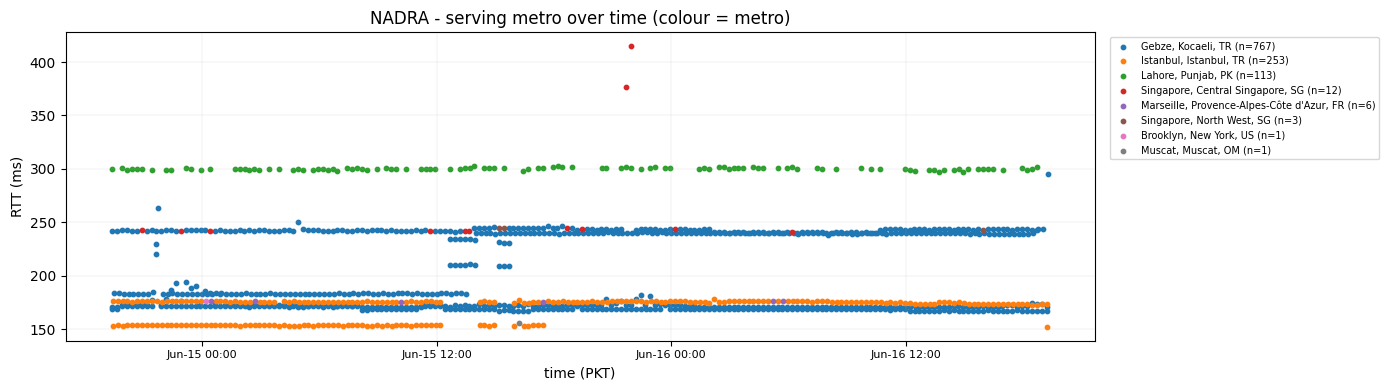

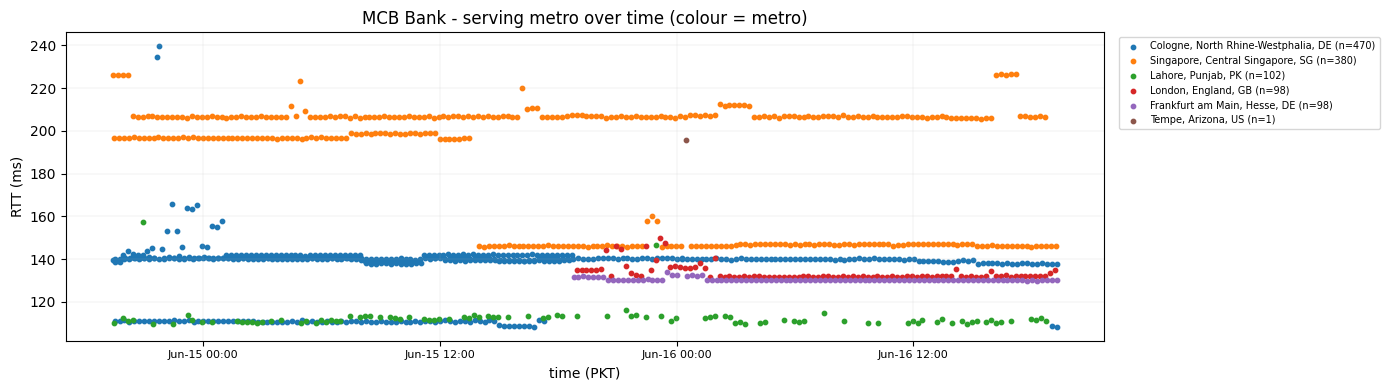

In [6]:
def plot_pop(site):
    g = ok[ok['target_label'] == site]
    metros = g['dest_location'].value_counts().index.tolist()
    cmap = plt.cm.tab10
    fig, ax = plt.subplots(figsize=(14, 4))
    for i, m in enumerate(metros):
        s = g[g['dest_location'] == m]
        ax.scatter(s['t'], s['dest_rtt_ms'], s=10, color=cmap(i % 10), label=f'{m} (n={len(s)})')
    ax.set_ylabel('RTT (ms)'); ax.set_xlabel('time (PKT)')
    ax.set_title(f'{site} - serving metro over time (colour = metro)')
    fmt_time(ax); ax.grid(True, lw=0.3, alpha=0.4)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout(); plt.show()

plot_pop('NADRA')
plot_pop('MCB Bank')

## 5. Diurnal (two days)

Median RTT by PKT hour for the offshore banks (should be flat = no congestion cycle)
and a local Cloudflare site for contrast. Uses all probes that reach each site.

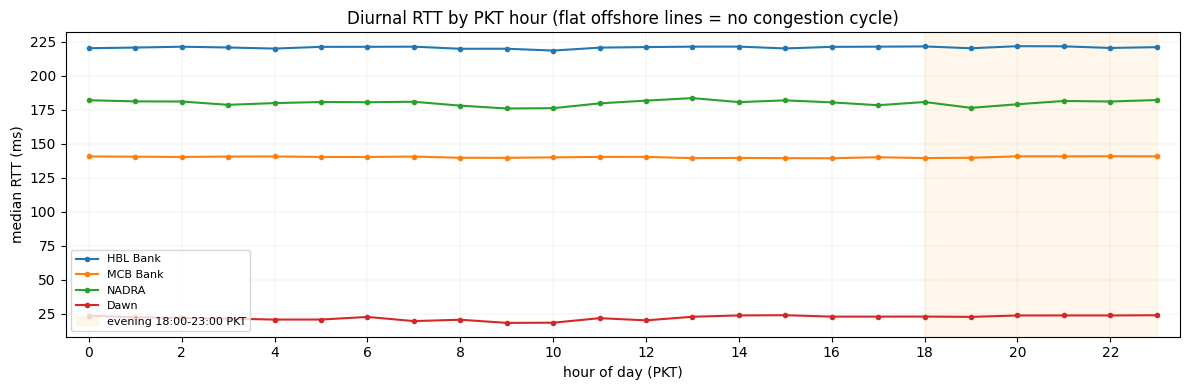

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
for s in ['HBL Bank', 'MCB Bank', 'NADRA', 'Dawn']:
    h = ok[ok['target_label'] == s].groupby('hour')['dest_rtt_ms'].median()
    ax.plot(h.index, h.values, marker='o', ms=3, label=s)
ax.axvspan(18, 23, color='orange', alpha=0.08, label='evening 18:00-23:00 PKT')
ax.set_xticks(range(0, 24, 2)); ax.set_xlim(-0.5, 23.5)
ax.set_xlabel('hour of day (PKT)'); ax.set_ylabel('median RTT (ms)')
ax.set_title('Diurnal RTT by PKT hour (flat offshore lines = no congestion cycle)')
ax.legend(fontsize=8); ax.grid(True, lw=0.3, alpha=0.4)
plt.tight_layout(); plt.show()

## 6. Path changes (real flips vs last-hop flicker)

Count of AS-path transitions per (site, probe). The PTCL anchor's huge counts are the
last-hop visibility flicker (e.g. `17557 > 13335` vs `17557`); the genuine changes are
NADRA / MCB's serving-metro flips.

In [8]:
rows = []
for (site, probe), g in df.sort_values('t').groupby(['target_label', 'probe_city']):
    p = g['asns_in_path'].dropna()
    ch = int((p.values[1:] != p.values[:-1]).sum()) if len(p) > 1 else 0
    metros = g['dest_location'].dropna().nunique()
    if ch > 0 or metros > 1:
        rows.append({'site': site, 'probe': probe, 'path_changes': ch,
                     'distinct_paths': int(p.nunique()), 'distinct_metros': metros})
pc = pd.DataFrame(rows).sort_values(['distinct_metros', 'path_changes'], ascending=False)
display(pc.reset_index(drop=True))

,site,probe,path_changes,distinct_paths,distinct_metros
0,NADRA,LocalInternetProj02 Cybernet Haripur,7,4,6
1,NADRA,LocalInternetProj05 PTCL Karachi,24,2,3
2,NADRA,LocalInternetProj04 Cybernet Karachi,7,4,3
3,Dawn,LocalInternetProj04 Cybernet Karachi,4,2,2
4,MCB Bank,Z COM Networks Lahore,3,2,2
5,Geo TV,LocalInternetProj04 Cybernet Karachi,2,2,2
6,MCB Bank,Nayatel Islamabad,2,2,2
7,MCB Bank,LocalInternetProj01 Lahore,1,2,2
8,Dawn,LocalInternetProj02 Cybernet Haripur,0,1,2
9,Geo TV,LocalInternetProj02 Cybernet Haripur,0,1,2


## 7. Dynamic egress ASN

Live-measured probe ASN vs registered. Equal everywhere here means none of the probes
switched ISP during the run (useful because two probes share AS9541 and two AS17557).

In [9]:
if 'probe_asn_reg' in df.columns:
    rows = []
    for probe, g in df.groupby('probe_city'):
        live = sorted(g['probe_asn'].dropna().unique())
        reg = sorted(g['probe_asn_reg'].dropna().unique())
        rows.append({'probe': probe, 'measured_asn': live, 'registered_asn': reg,
                     'stable': live == reg and len(live) == 1})
    display(pd.DataFrame(rows))
else:
    print('no probe_asn_reg column (older schema)')

,probe,measured_asn,registered_asn,stable
0,LocalInternetProj01 Lahore,[136174],[136174],True
1,LocalInternetProj02 Cybernet Haripur,[9541],[9541],True
2,LocalInternetProj04 Cybernet Karachi,[9541],[9541],True
3,LocalInternetProj05 PTCL Karachi,[17557],[17557],True
4,Nayatel Islamabad,[23674],[23674],True
5,PTCL (anchor) LUMS,[17557],[17557],True
6,Transworld Lahore,[38193],[38193],True
7,Z COM Networks Lahore,[152605],[152605],True
